# How many ideas did you try?

A simulation with no finance in it at all. We create strategies with **zero** true skill and see how good the best one looks, then apply the corrections the platform uses.

**What you will learn:** why the best of many random strategies looks impressive, what the deflated Sharpe ratio and the Reality Check do about it, and what false-discovery control buys.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.backtest.metrics import deflated_sharpe_ratio, probabilistic_sharpe_ratio
from src.validation.multiple_testing import white_reality_check

## 200 strategies of pure noise

Each is a year-by-year coin toss with the volatility of a typical ETF book. Five years of daily returns.

best Sharpe 0.94; median 0.02; share above 0.5: 11.0%


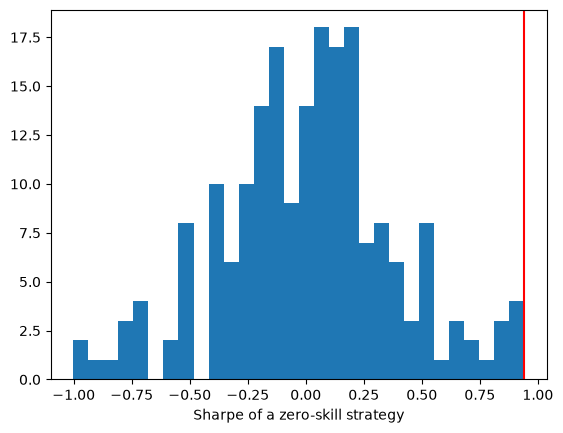

In [2]:
rng = np.random.default_rng(3)
n_days, n_strats = 252 * 5, 200
R = rng.normal(0, 0.01, size=(n_days, n_strats))
sharpe = np.sqrt(252) * R.mean(axis=0) / R.std(axis=0, ddof=1)
print(f'best Sharpe {sharpe.max():.2f}; median {np.median(sharpe):.2f}; share above 0.5: {np.mean(sharpe > 0.5):.1%}')
plt.hist(sharpe, bins=30); plt.axvline(sharpe.max(), color='red'); plt.xlabel('Sharpe of a zero-skill strategy'); plt.show()

The best of 200 coin-flip strategies has a Sharpe above 1, with *no skill at all*. Reporting it alone is how fake alpha is born.

## The deflated Sharpe ratio

It asks: given that we tried 200 things, how likely is it that the best one beats what the best of 200 random strategies would show?

In [3]:
best = int(sharpe.argmax())
r = pd.Series(R[:, best])
from scipy.stats import skew, kurtosis
alone = probabilistic_sharpe_ratio(sharpe[best], 0.0, n_days, skew(r), kurtosis(r, fisher=False))
deflated = deflated_sharpe_ratio(sharpe[best], n_strats, n_days, skew(r), kurtosis(r, fisher=False))
print(f'probability the true Sharpe is above zero if you pretend it was the only idea: {alone:.2f}; counting all {n_strats} tries: {deflated:.2f}')

probability the true Sharpe is above zero if you pretend it was the only idea: 0.98; counting all 200 tries: 0.25


## White's Reality Check

A bootstrap test that the best strategy beats zero, with the search built into the null.

In [4]:
out = white_reality_check(R, n_samples=500, mean_block=21.0, seed=7)
out

{'statistic': 0.020733054229993074,
 'p_value': 0.944,
 'best_index': 148,
 'best_mean': 0.0005840876331998571}

## False discovery control

Test every strategy's mean at 5%: about 10 of the 200 will 'work'. Benjamini-Hochberg keeps the share of false discoveries among the declared winners under control.

In [5]:
from scipy import stats
t = R.mean(axis=0) / (R.std(axis=0, ddof=1) / np.sqrt(n_days))
p = 2 * stats.norm.sf(np.abs(t))
print('naive 5% rejections:', int((p < 0.05).sum()))
from src.validation.forecast_tests import benjamini_hochberg
print('after Benjamini-Hochberg at 10%:', int(benjamini_hochberg(p, 0.10).sum()))

naive 5% rejections: 7


after Benjamini-Hochberg at 10%: 0


## Your turn

Plant a real edge (add a small positive drift to ten of the strategies) and see how many survive the corrections. That is power: Stage 39 of the platform does this properly.